# 09 · Mid-term RL Unit 2 — Finite MDP and Dynamic Programming

The full project originally used a five-stage MDP over 2,100 configurations.

For the mid-term, use a **small finite MDP**:

- states = 3 signal-quality contexts;
- actions = 5 wavelets;
- transition = selected action leads to a terminal state;
- reward = average training reward for that state/action;
- gamma = 1.

This is deliberately a one-step finite MDP so that Policy Evaluation, Policy Improvement, Policy Iteration and Value Iteration are easy to implement and defend.

The multi-stage 2,100-action MDP remains an end-semester extension.


In [1]:
%run ../common/00_config.ipynb
use_half("midsem", oracle="classical")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

reward_data = joblib.load(P["processed"] / "midterm_reward_data.joblib")
states = np.load(P["processed"] / "midterm_states.npz")

wavelets = reward_data["wavelets"]
R = reward_data["reward_train"]
state_train = states["state_train"]

K = 3
A = len(wavelets)
gamma = 1.0

# Empirical MDP reward model:
# Rbar[s, a] = mean reward observed for action a in state s.
Rbar = np.zeros((K, A), dtype=float)
counts = np.zeros((K, A), dtype=int)

for s in range(K):
    idx = np.where(state_train == s)[0]
    for a in range(A):
        counts[s, a] = len(idx)
        Rbar[s, a] = R[idx, a].mean() if len(idx) else 0.0

print("Reward table shape:", Rbar.shape)
print(pd.DataFrame(Rbar, index=[f"state_{s}" for s in range(K)], columns=wavelets).round(4))


Python environment is working
PyTorch: 2.14.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


CirCor version 1.0.3
midsem: results -> results/midsem/ | reward oracle: classical


Reward table shape: (3, 5)
            db4     db6     db8    sym4   coif3
state_0  0.1419  0.0485  0.3382  0.3144  0.3126
state_1  0.1304  0.0659  0.2496  0.2533  0.2532
state_2  0.1830  0.1887  0.2974  0.2951  0.2965


## 1. Policy Evaluation

For the one-step MDP:

**V(s) = R(s, π(s))**

because the selected action transitions directly to the terminal state.


In [2]:
def policy_evaluation(Rbar, policy, gamma=1.0):
    V = np.zeros(Rbar.shape[0], dtype=float)

    for s in range(Rbar.shape[0]):
        a = int(policy[s])
        V[s] = Rbar[s, a]

    return V


def policy_improvement(Rbar, V=None, gamma=1.0):
    # One-step transition to terminal state, so Q(s,a)=R(s,a).
    Q = Rbar.copy()
    return np.argmax(Q, axis=1)


def policy_iteration(Rbar, gamma=1.0, max_iter=50):
    policy = np.zeros(Rbar.shape[0], dtype=int)

    for iteration in range(max_iter):
        V = policy_evaluation(Rbar, policy, gamma)
        new_policy = policy_improvement(Rbar, V, gamma)

        if np.array_equal(new_policy, policy):
            return {
                "policy": policy,
                "V": V,
                "iterations": iteration + 1
            }

        policy = new_policy

    return {
        "policy": policy,
        "V": policy_evaluation(Rbar, policy, gamma),
        "iterations": max_iter
    }


def value_iteration(Rbar, gamma=1.0, max_iter=50, tol=1e-10):
    V = np.zeros(Rbar.shape[0], dtype=float)
    deltas = []

    for iteration in range(max_iter):
        new_V = np.max(Rbar, axis=1)
        delta = float(np.max(np.abs(new_V - V)))
        deltas.append(delta)
        V = new_V

        if delta < tol:
            break

    policy = np.argmax(Rbar, axis=1)

    return {
        "policy": policy,
        "V": V,
        "iterations": iteration + 1,
        "deltas": deltas
    }

initial_policy = np.zeros(K, dtype=int)

V0 = policy_evaluation(Rbar, initial_policy)
pi = policy_iteration(Rbar, gamma)
vi = value_iteration(Rbar, gamma)

print("Initial policy:", [wavelets[a] for a in initial_policy])
print("Policy-iteration policy:", [wavelets[a] for a in pi["policy"]])
print("Value-iteration policy:", [wavelets[a] for a in vi["policy"]])
print("Policy iteration iterations:", pi["iterations"])
print("Value iteration iterations:", vi["iterations"])
print("Policies agree:", np.array_equal(pi["policy"], vi["policy"]))


Initial policy: ['db4', 'db4', 'db4']
Policy-iteration policy: ['db8', 'sym4', 'db8']
Value-iteration policy: ['db8', 'sym4', 'db8']
Policy iteration iterations: 2
Value iteration iterations: 2
Policies agree: True


## 2. Compare the learned policies

The DP policy is computed from the empirical state/action reward table.

This is a reference policy for the simplified mid-term MDP.


In [3]:
def evaluate_policy_on_validation(policy, state_values, prob_matrix, y_true):
    chosen = np.asarray(policy)[state_values]
    p = prob_matrix[np.arange(len(y_true)), chosen]
    pred = (p >= 0.5).astype(int)

    return {
        "macro_f1": f1_score(y_true, pred, average="macro"),
        "balanced_acc": balanced_accuracy_score(y_true, pred),
        "auroc": roc_auc_score(y_true, p)
    }

from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score

val_idx = reward_data["val_idx"]
state_val = states["state_val"]
y = reward_data["y"]
val_prob = reward_data["val_prob"]

fixed_policy = np.full(K, wavelets.index("db6"))

rows = []
for name, policy in [
    ("Fixed db6", fixed_policy),
    ("Policy iteration", pi["policy"]),
    ("Value iteration", vi["policy"])
]:
    m = evaluate_policy_on_validation(
        policy,
        state_val,
        val_prob[val_idx],
        y[val_idx]
    )
    rows.append({"method": name, **m})

dp_results = pd.DataFrame(rows)
dp_results.to_csv(P["tables"] / "09_midterm_dp_results.csv", index=False)

print("DP policy by state:")
for s, a in enumerate(vi["policy"]):
    print(f"  state {s} -> {wavelets[a]}")

dp_results


DP policy by state:
  state 0 -> db8
  state 1 -> sym4
  state 2 -> db8


,method,macro_f1,balanced_acc,auroc
0,Fixed db6,0.489229,0.545213,0.592905
1,Policy iteration,0.611500,0.650482,0.684409
2,Value iteration,0.611500,0.650482,0.684409


## 3. Policy comparison plot

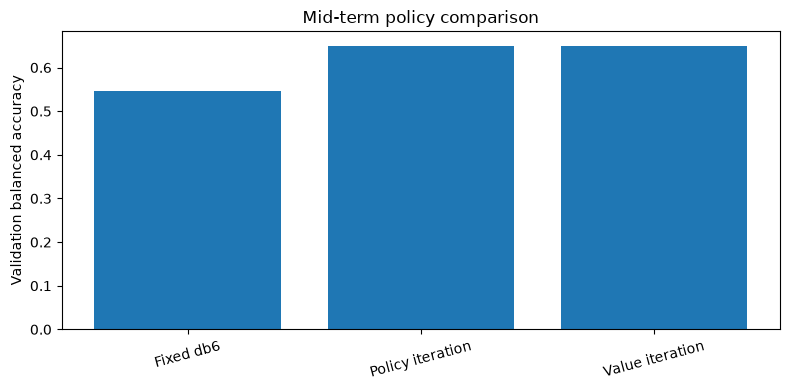

['C:\\Users\\roshh\\Desktop\\rl\\version 2\\results\\midsem\\midterm_dp_policy.joblib']

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(dp_results))
ax.bar(x, dp_results["balanced_acc"])
ax.set_xticks(x)
ax.set_xticklabels(dp_results["method"], rotation=15)
ax.set_ylabel("Validation balanced accuracy")
ax.set_title("Mid-term policy comparison")
plt.tight_layout()
savefig(fig, "09_midterm_dp_comparison")
plt.show()

joblib.dump(
    {
        "Rbar": Rbar,
        "policy_iteration": pi,
        "value_iteration": vi,
        "wavelets": wavelets
    },
    P["results"] / "midterm_dp_policy.joblib",
    compress=3
)


### Unit 2 mapping

This notebook demonstrates:

- **Finite MDP:** state, action, reward, transition and terminal state.
- **Policy Evaluation:** calculate V for a fixed policy.
- **Policy Improvement:** choose actions with higher expected value.
- **Policy Iteration:** evaluation → improvement → repeat.
- **Value Iteration:** repeatedly update state values using the best action.

The final-semester MDP can replace this small one-step environment with the complete sequential recipe-selection problem.
